#**Séries temporais do sensor *Wide-Field Imager* (WFI) para mapeamento de áreas queimadas no Cerrado**

###**Agregação temporal [3/5]**

No post anterior (02_transformacao_series_temporais.ipynb), vimos como utilizar os rótulos/*labels* do *dataset* (disponível em: https://doi.org/10.57760/sciencedb.14040) na identificação de padrões temporais de áreas queimadas, considerando as células de 500 m x 500 m como unidades de mapeamento. Agora vamos trabalhar com os **dados espectrais** disponíveis no mesmo *dataset*, compostos por séries temporais diárias de bandas e índices espectrais:

| Banda / Índice | Prefixo | Colunas |
|----------------|---------|---------|
| Blue | `a_` | [2 : 1096] |
| Green | `b_` | [1097 : 2191] |
| Red | `c_` | [2192 : 3286] |
| NIR | `d_` | [3287 : 4381] |
| BAI | `e_` | [4382 : 5476] |
| EVI | `f_` | [5477 : 6571] |
| GEMI | `g_` | [6572 : 7666] |
| NDVI | `h_` | [7667 : 8761] |
| NDWI | `i_` | [8762 : 9856] |

Cada uma dessas colunas contém observações diárias ao longo de três anos (2020–2022), totalizando 1.095 observações por atributo espectral.

**O desafio:** como extrair e estruturar essas séries para análise, preparando os dados para tarefas como classificação de áreas queimadas?

Veremos três possíveis abordagens:
1) Com dados diários.
2) Com dados agregados em 16 dias.
3) Com dados agregados em 30 dias.

Para compreender melhor o *dataset*, consulte: https://doi.org/10.1080/20964471.2025.2463731

**1) *Download* e preparação dos dados**

Antes de iniciarmos a análise, precisamos obter a base de dados. O conjunto utilizado neste exercício está disponível publicamente e reúne os registros do sensor WFI entre 2020 e 2022... Convertamos o arquivo CSV para Parquet, um formato mais eficiente para leitura e manipulação de grandes volumes de dados.

**Observação**: esse *dataset* contém diversas outras colunas, mas nesse exercício nos focaremos nas colunas que contém as reflectâncias TOA (*top of atmosphere*) da banda NIR (colunas com o prefixo 'd'). Para entender melhor o *dataset*, consulte: https://doi.org/10.1080/20964471.2025.2463731

In [ ]:
# ============================================
# FUNÇÕES AUXILIARES
# ============================================

import requests
from tqdm.auto import tqdm

def download(url: str, output: str) -> None:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(output, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=output.split("/")[-1],
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

# ============================================
# DOWNLOAD E PREPARAÇÃO DOS DADOS
# ============================================

import pandas as pd # trabalha com dataframes
import os

# ----------------------------------------------------------------------------
# CAMINHOS E URLS
# ----------------------------------------------------------------------------

CSV_URL = "https://download.scidb.cn/download?fileId=e22fe8b8fa7b696516664d76a42ac2fe&path=/V4/Dataset_WFI.csv&fileName=Dataset_WFI.csv" # link do dataset no repositório ScienceDB

# Criar diretório no armazenamento temporário do Colab
BASE_DIR = "/content/ScienceDB/Dataset"
csv_path = os.path.join(BASE_DIR, "Dataset_WFI.csv")
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")

# Criar diretório se não existir
os.makedirs(BASE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# DOWNLOAD E CONVERSÃO DE CSV PARA PARQUET
# ----------------------------------------------------------------------------

if not os.path.exists(parquet_path):
    # Baixar CSV se necessário
    if not os.path.exists(csv_path):
        download(CSV_URL, csv_path)
    else:
        print(f"✓ CSV já existe: {csv_path}")

    # Converter para Parquet (formato mais eficiente)
    print("Convertendo CSV para Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, compression="snappy")

    # Liberar memória e limpar
    del df
    os.remove(csv_path)
    print(f"✓ Parquet salvo: {parquet_path}")
    print(f"✓ CSV removido: {csv_path}") # como o csv é pesado, removemos ele após a conversão para Parquet
else:
    print(f"✓ Parquet já existe: {parquet_path}")

print("\n✓ Arquivo de dados pronto!")

Dataset_WFI.csv:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Convertendo CSV para Parquet...


/tmp/ipykernel_3048/1162010271.py:58: DtypeWarning: Columns (9856,9857,9858) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✓ Parquet salvo: /content/ScienceDB/Dataset/Dataset_WFI.parquet
✓ CSV removido: /content/ScienceDB/Dataset/Dataset_WFI.csv

✓ Arquivo de dados pronto!


... mas antes, vamos identificar os dias de picos de detecções dos anos de 2020, 2021 e 2022, pois isso será útil na visualização das análises que faremos

In [ ]:
# ============================================
# DIAS DE PICO DE DETECÇÃO DE QUEIMADAS (2020-2022)
# ============================================

import pandas as pd
from datetime import datetime

parquet_path = "/content/ScienceDB/Dataset/Dataset_WFI.parquet"
df = pd.read_parquet(parquet_path)

print("=" * 50)
print("PICOS DE DETECÇÃO DE QUEIMADAS (2020-2022)")
print("=" * 50)

for ano in [2020, 2021, 2022]:
    col = f"date_{str(ano)[-2:]}" # 'date_' são as três colunas com as datas que constam nas células rotuladas como queimada
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()] # conta a quantidade de células com dados nas colunas date_20, date_21 e date_22 diferentes de Null/NoData

    if len(contagem) > 0:
        pico_data = contagem.idxmax()
        pico_valor = contagem.max()
        data_obj = datetime.strptime(pico_data, "%d-%m-%y")

        print(f"\n{ano}:")
        print(f"  Pico: {data_obj.strftime('%d/%m/%Y')} ({pico_valor:,} células)")

PICOS DE DETECÇÃO DE QUEIMADAS (2020-2022)

2020:
  Pico: 05/10/2020 (1,750 células)

2021:
  Pico: 16/09/2021 (605 células)

2022:
  Pico: 12/10/2022 (673 células)


**2) Abordagem 1 - Com dados diários**

Consideraremos, para simplificar o processamento, apenas os dados da banda do **infravermelho próximo** (*near infrared* - NIR), que é uma das mais importantes no mapeamento de áreas queimadas.

Com base nos dias de pico (de detecções) de cada ano, vamos analisar:

- 300 amostras aleatórias de células que foram anotadas/rotuladas como queimadas no ano de análise.
- 300 amostras aleatórias de células que não registraram queimadas no ano (classe "sem queimada") de análise.

Os gráficos a seguir mostram os resultados dos dados diários e localiza o dia de pico ao longo da série temporal. Também estima a média das 300 observações de cada classe (queimado vs. não queimado).

Carregando dados...
✓ Dataset carregado: 38,957 linhas, 9,862 colunas

Analisando 2020...

Analisando 2021...

Analisando 2022...


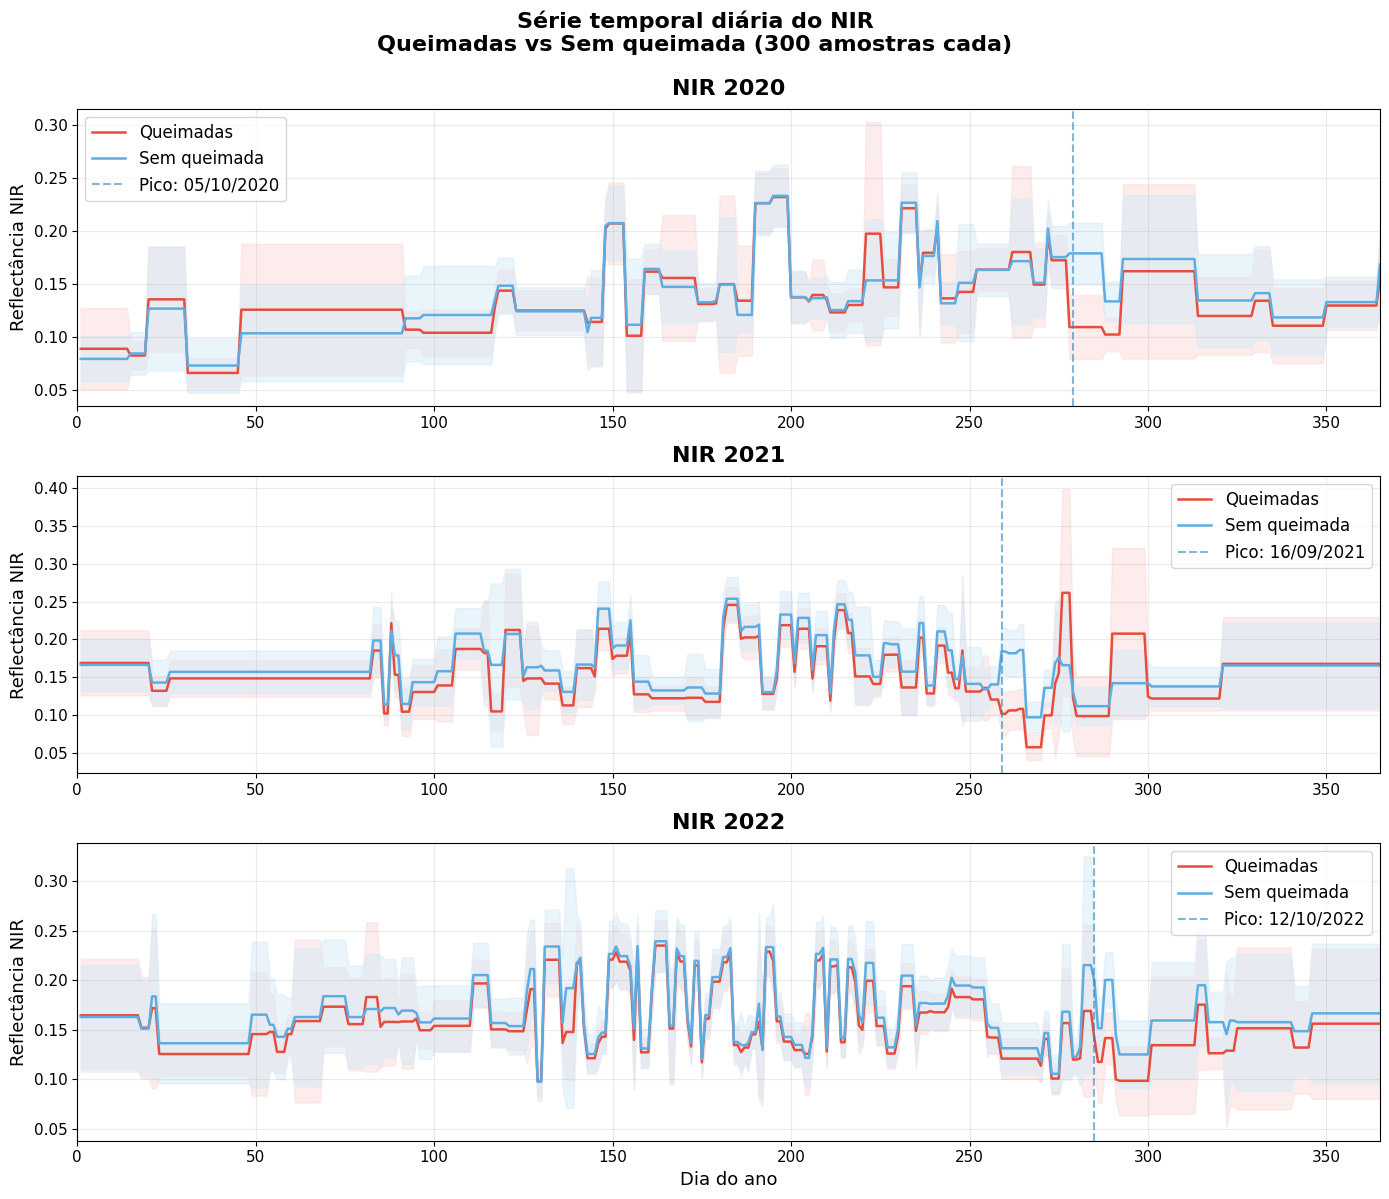

In [ ]:
# ============================================
# ANÁLISE ESPECTRAL NIR - DADOS DIÁRIOS (2020-2022)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

parquet_path = "/content/ScienceDB/Dataset/Dataset_WFI.parquet"

# ----------------------------------------------------------------------------
# CARREGAR DADOS
# ----------------------------------------------------------------------------

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# FUNÇÕES AUXILIARES
# ----------------------------------------------------------------------------

def get_nir_cols(ano):
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano): # função que encontra o pico de queimadas (Simplemente é a data com o maior número de células rotuladas como queimadas)
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def analisar_ano(ano, n_amostras=300):
    nir_cols = get_nir_cols(ano) # utiliza apenas as colunas com observações do NIR
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None

    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False) # sorteia 300 amostras aleatórias de áreas queimadas rotuladas na data de pico
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    # Extrair séries diárias (1ª abordagem))
    series_q = df.loc[amostras_q, nir_cols]
    series_sq = df.loc[amostras_sq, nir_cols]

    media_q = series_q.mean(axis=0)
    media_sq = series_sq.mean(axis=0)
    std_q = series_q.std(axis=0)
    std_sq = series_sq.std(axis=0)

    # Dias do ano (1-365)
    dias = np.arange(1, len(media_q) + 1)

    data_obj = datetime.strptime(pico_data, "%d-%m-%y")
    data_formatada = data_obj.strftime("%d/%m/%Y")
    dia_pico = data_obj.timetuple().tm_yday

    return {
        "ano": ano,
        "media_q": media_q.values,
        "media_sq": media_sq.values,
        "std_q": std_q.values,
        "std_sq": std_sq.values,
        "dias": dias,
        "data_pico": data_formatada,
        "dia_pico": dia_pico,
        "amostras_q": len(amostras_q),
        "amostras_sq": len(amostras_sq)
    }

# ----------------------------------------------------------------------------
# ANALISAR 2020, 2021, 2022
# ----------------------------------------------------------------------------

anos = [2020, 2021, 2022]
resultados = {}

for ano in anos:
    print(f"\nAnalisando {ano}...")
    resultados[ano] = analisar_ano(ano)

# ----------------------------------------------------------------------------
# GRÁFICOS DIÁRIOS
# ----------------------------------------------------------------------------

cores = {
    "queimada": "#E74C3C",
    "queimada_fill": "#FADBD8",
    "sem_queimada": "#5DADE2",
    "sem_queimada_fill": "#D6EAF8",
    "pico": "#2E86C1"
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, ano in enumerate(anos):
    r = resultados[ano]
    if r is None:
        continue

    ax = axes[i]

    # Queimadas
    ax.plot(r["dias"], r["media_q"], color=cores["queimada"], linewidth=1.8, label="Queimadas")
    ax.fill_between(r["dias"], r["media_q"] - r["std_q"], r["media_q"] + r["std_q"],
                    color=cores["queimada_fill"], alpha=0.5)

    # Sem queimada
    ax.plot(r["dias"], r["media_sq"], color=cores["sem_queimada"], linewidth=1.8, label="Sem queimada")
    ax.fill_between(r["dias"], r["media_sq"] - r["std_sq"], r["media_sq"] + r["std_sq"],
                    color=cores["sem_queimada_fill"], alpha=0.5)

    # Linha do pico
    ax.axvline(r["dia_pico"], color=cores["pico"], linestyle="--", alpha=0.6, linewidth=1.5,
               label=f"Pico: {r['data_pico']}")

    ax.set_title(f"NIR {ano}", fontsize=16, fontweight="bold", pad=10)
    ax.set_ylabel("Reflectância NIR", fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=12, loc='best')
    ax.set_xlim(0, 365)

axes[-1].set_xlabel("Dia do ano", fontsize=13)

plt.suptitle("Série temporal diária do NIR\nQueimadas vs Sem queimada (300 amostras cada)",
             fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

O principal desafio dessa abordagem (com dados diários) é que a disponibilidade de imagens do WFI varia ao longo do tempo, mesmo considerando os satélites CBERS-4, CBERS-4A e AMAZONIA-1. O *plot* de 2020, por exemplo, evidencia bem esse problema, pois o seu aspecto 'quadrado' é causado pelo menor número de imagens disponíveis nesse ano.

Quando o *dataset* foi construído, as imagens de 2020 do CBERS-4 não estavam disponíveis no catálogo do INPE e o AMAZONIA-1 ainda não tinho sido lançado (o que aconteceu em 2021). Dessa forma, 2020 contém imagens apenas do CBERS-4A, com um tempo de revisita de 3 a 5 dias. Para construir o *dataset*, foram excluídas as imagens com nuvens, de modo que os meses de outubro a abril tendem a possuir menos observações que de maio a setembro.

Para o mapeamento de áreas queimadas isso não é necessariamente ruim, visto que elas ocorrem, sobretudo, no período seco. Contudo, as séries temporais referentes aos três anos não apresentam uma distribuição temporal regular, o que pode dificultar a aplicação de algoritmos de *machine learning*. Uma estratégia para contornar essa limitação é realizar uma agregação temporal das observações, como o cálculo de médias para janelas de 16 dias.

**3) Abordagem 2 - Com dados agregados de 16 dias**

A agregação a cada 16 dias reduz a dimensionalidade da série, suaviza ruídos e minimiza o efeito de observações faltantes, resultando em uma série mais regular e estável para análise. Com cerca de 23 observações por ano, essa abordagem equilibra resolução temporal e métricas estatísticas.

Os gráficos a seguir apresentam a série agregada do NIR para cada ano, com a média das 300 amostras por classe e o dia de pico destacado.

Carregando dados...
✓ Dataset carregado: 38,957 linhas, 9,862 colunas

Analisando 2020...

Analisando 2021...

Analisando 2022...


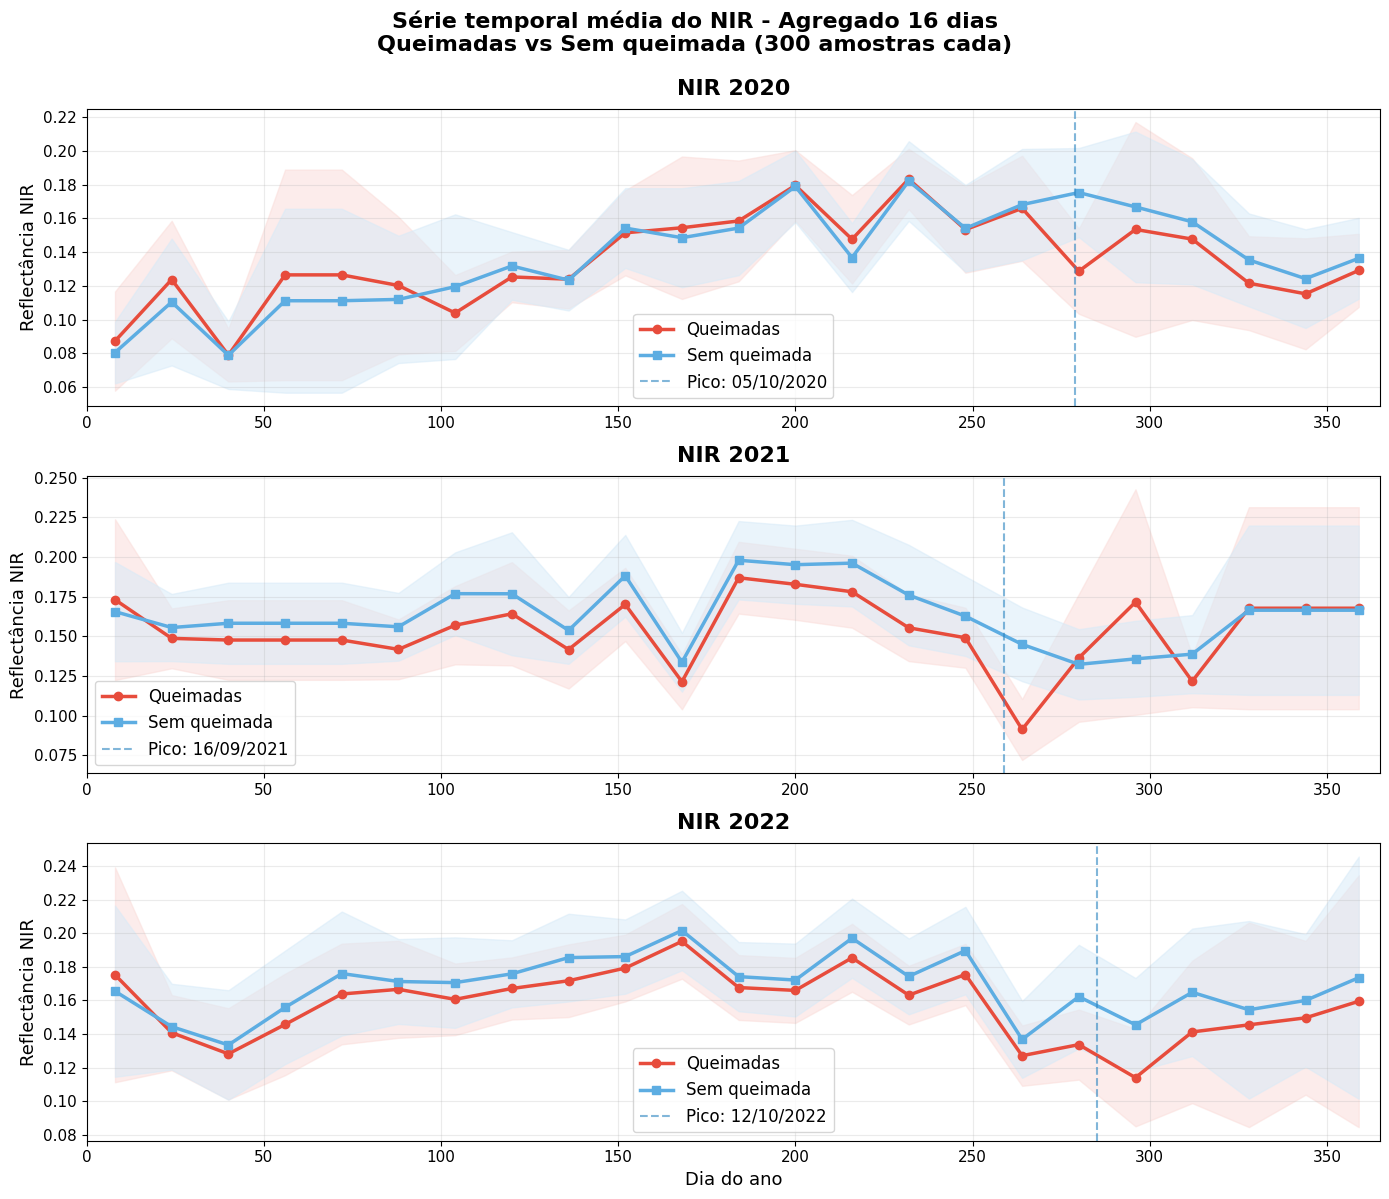

In [ ]:
# ============================================
# ANÁLISE ESPECTRAL NIR - AGREGADO 16 DIAS (2020-2022)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

parquet_path = "/content/ScienceDB/Dataset/Dataset_WFI.parquet"

# ----------------------------------------------------------------------------
# CARREGAR DADOS
# ----------------------------------------------------------------------------

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# FUNÇÕES AUXILIARES
# ----------------------------------------------------------------------------

def get_nir_cols(ano):
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano):
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def agregar_16_dias(serie, nir_cols):
    num_cols = len(nir_cols)
    num_grupos = (num_cols + 15) // 16
    medias = []
    for i in range(num_grupos):
        inicio = i * 16
        fim = min((i + 1) * 16, num_cols)
        grupo_cols = nir_cols[inicio:fim]
        medias.append(serie[grupo_cols].mean())
    return np.array(medias)

def analisar_ano(ano, n_amostras=300):
    nir_cols = get_nir_cols(ano)
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None

    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False)
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    medias_q = []
    medias_sq = []
    for idx in amostras_q:
        medias_q.append(agregar_16_dias(df.loc[idx, nir_cols], nir_cols))
    for idx in amostras_sq:
        medias_sq.append(agregar_16_dias(df.loc[idx, nir_cols], nir_cols))

    medias_q = np.array(medias_q)
    medias_sq = np.array(medias_sq)

    num_grupos = len(medias_q.mean(axis=0))
    dias_centro = [(i*16 + min((i+1)*16, 365) + 1) // 2 for i in range(num_grupos)]

    data_obj = datetime.strptime(pico_data, "%d-%m-%y")
    data_formatada = data_obj.strftime("%d/%m/%Y")
    dia_pico = data_obj.timetuple().tm_yday

    return {
        "ano": ano,
        "media_q": medias_q.mean(axis=0),
        "media_sq": medias_sq.mean(axis=0),
        "std_q": medias_q.std(axis=0),
        "std_sq": medias_sq.std(axis=0),
        "dias_centro": dias_centro,
        "data_pico": data_formatada,
        "dia_pico": dia_pico,
        "amostras_q": len(amostras_q),
        "amostras_sq": len(amostras_sq)
    }

# ----------------------------------------------------------------------------
# ANALISAR 2020, 2021, 2022
# ----------------------------------------------------------------------------

anos = [2020, 2021, 2022]
resultados = {}

for ano in anos:
    print(f"\nAnalisando {ano}...")
    resultados[ano] = analisar_ano(ano)

# ----------------------------------------------------------------------------
# GRÁFICOS COM CORES PASTÉIS E AZUL
# ----------------------------------------------------------------------------

# Paleta de cores pasteis
cores = {
    "queimada": "#E74C3C",      # vermelho suave
    "queimada_fill": "#FADBD8",  # vermelho pastel
    "sem_queimada": "#5DADE2",   # azul claro
    "sem_queimada_fill": "#D6EAF8",  # azul pastel
    "pico": "#2E86C1"            # azul médio
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, ano in enumerate(anos):
    r = resultados[ano]
    if r is None:
        continue

    ax = axes[i]

    # Queimadas (vermelho)
    ax.plot(r["dias_centro"], r["media_q"], color=cores["queimada"], linewidth=2.5,
            marker='o', markersize=6, label="Queimadas")
    ax.fill_between(r["dias_centro"], r["media_q"] - r["std_q"], r["media_q"] + r["std_q"],
                    color=cores["queimada_fill"], alpha=0.5)

    # Sem queimada (azul)
    ax.plot(r["dias_centro"], r["media_sq"], color=cores["sem_queimada"], linewidth=2.5,
            marker='s', markersize=6, label="Sem queimada")
    ax.fill_between(r["dias_centro"], r["media_sq"] - r["std_sq"], r["media_sq"] + r["std_sq"],
                    color=cores["sem_queimada_fill"], alpha=0.5)

    # Linha do pico
    ax.axvline(r["dia_pico"], color=cores["pico"], linestyle="--", alpha=0.6, linewidth=1.5,
               label=f"Pico: {r['data_pico']}")

    ax.set_title(f"NIR {ano}", fontsize=16, fontweight="bold", pad=10)
    ax.set_ylabel("Reflectância NIR", fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=12, loc='best')
    ax.set_xlim(0, 365)

axes[-1].set_xlabel("Dia do ano", fontsize=13)

plt.suptitle("Série temporal média do NIR - Agregado 16 dias\nQueimadas vs Sem queimada (300 amostras cada)",
             fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

Um padrão observado nos resultados agregados em intervalos de 16 dias, já identificado também nas séries diárias, é o aumento da diferença entre as médias das células com ocorrência de queimadas e aquelas sem registro de queimadas nas datas de pico de cada ano. Esse comportamento está associado ao efeito do fogo sobre a vegetação, que provoca dados à cobertura vegetal e alterações em sua estrutura, resultando em uma redução acentuada, embora temporária, da resposta espectral na banda do NIR.

**Observação**: no NIR, a vegetação saudável apresenta, normalmente, alta reflectância, enquanto áreas queimadas apresentam baixa reflectância.

**4) Abordagem 3 - Com dados agregados de 30 dias**

Uma agregação temporal de 30 dias suaviza ainda mais a série e pode atenuar respostas espectrais, especialmente de alvos cujas diferenças são mais sutis. Mas, para áreas queimadas, podemos esperar que esse nível de agregação ainda preserve o comportamento geral da série temporal, caracterizado por uma queda abrupta de reflectância no NIR no mês da ocorrência do fogo, seguida por uma recuperação gradual (ocasionada por verdejamento após a diminuição de cinzas e carvão, por exemplo).

Carregando dados...
✓ Dataset carregado: 38,957 linhas, 9,862 colunas

Analisando 2020...

Analisando 2021...

Analisando 2022...


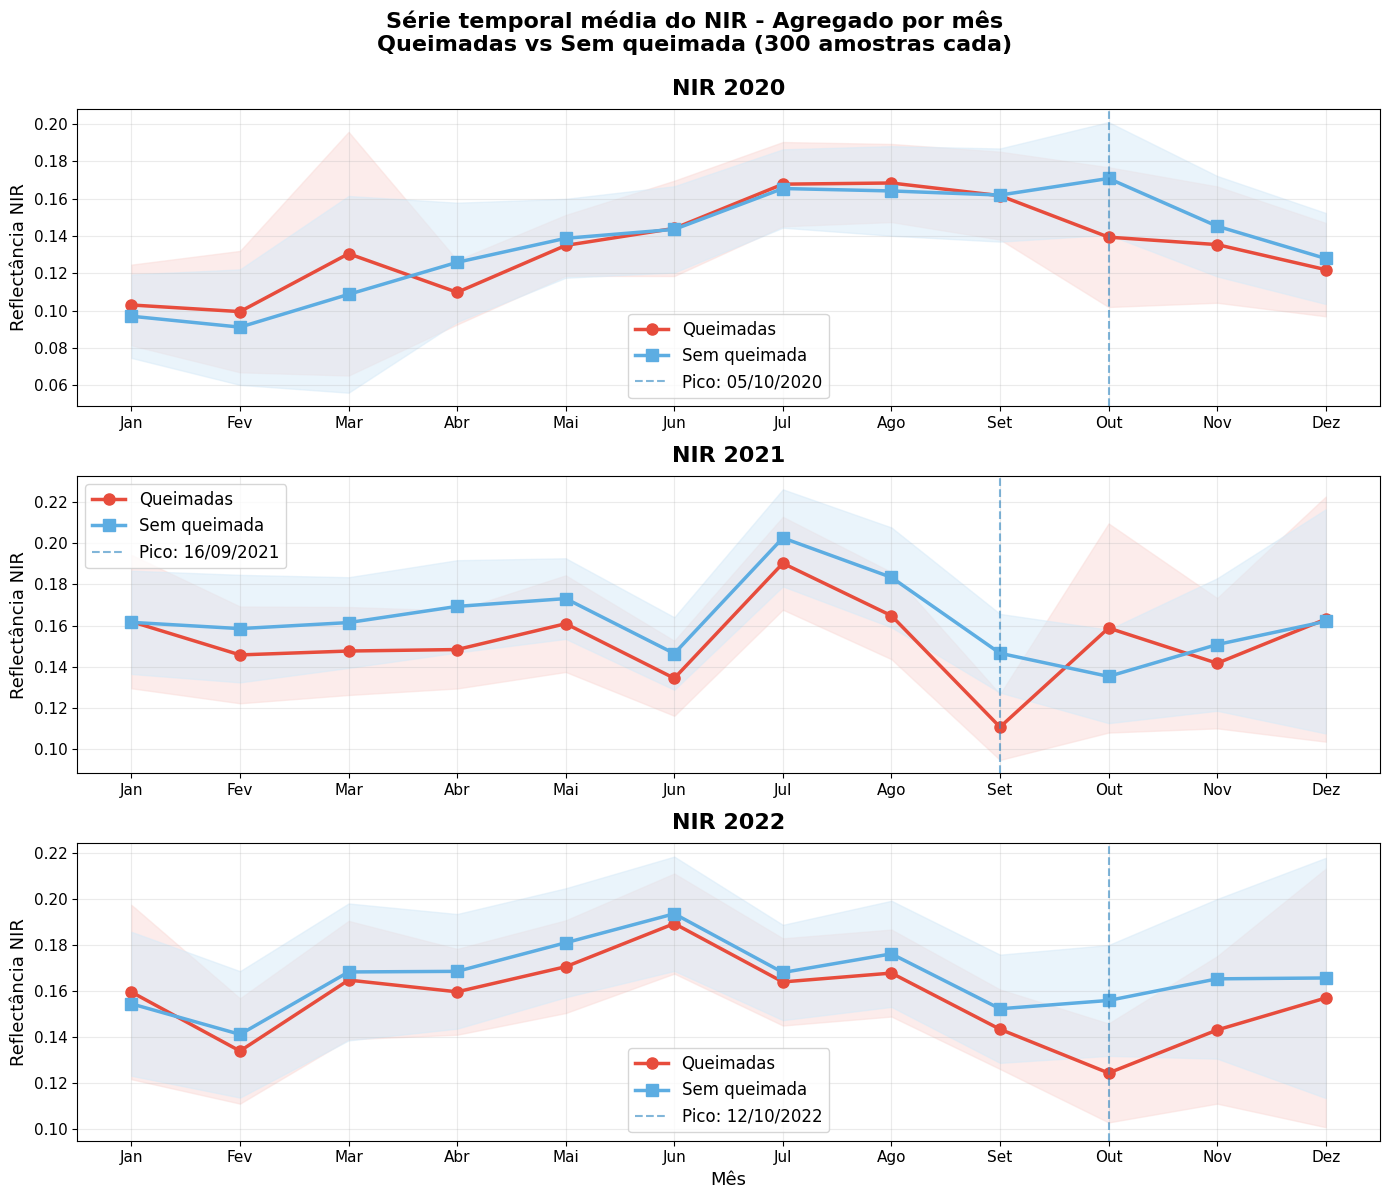

In [ ]:
# ============================================
# ANÁLISE ESPECTRAL NIR - DADOS AGREGADOS (MENSAL) - 2020-2022
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

parquet_path = "/content/ScienceDB/Dataset/Dataset_WFI.parquet"

# ----------------------------------------------------------------------------
# CARREGAR DADOS
# ----------------------------------------------------------------------------

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# FUNÇÕES AUXILIARES
# ----------------------------------------------------------------------------

def get_nir_cols(ano):
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano):
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def agregar_por_mes(serie, nir_cols):
    """Agrupa colunas por mês e calcula a média."""
    # Dias por mês (2020 é bissexto)
    dias_por_mes = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    medias = []
    idx = 0
    for dias_mes in dias_por_mes:
        grupo_cols = nir_cols[idx:idx + dias_mes]
        medias.append(serie[grupo_cols].mean())
        idx += dias_mes
    return np.array(medias)

def analisar_ano_mensal(ano, n_amostras=300):
    nir_cols = get_nir_cols(ano)
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None

    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False)
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    medias_q = []
    medias_sq = []
    for idx in amostras_q:
        medias_q.append(agregar_por_mes(df.loc[idx, nir_cols], nir_cols))
    for idx in amostras_sq:
        medias_sq.append(agregar_por_mes(df.loc[idx, nir_cols], nir_cols))

    medias_q = np.array(medias_q)
    medias_sq = np.array(medias_sq)

    data_obj = datetime.strptime(pico_data, "%d-%m-%y")
    mes_pico = data_obj.month - 1  # 0-indexado para o gráfico

    return {
        "ano": ano,
        "media_q": medias_q.mean(axis=0),
        "media_sq": medias_sq.mean(axis=0),
        "std_q": medias_q.std(axis=0),
        "std_sq": medias_sq.std(axis=0),
        "mes_pico": mes_pico,
        "data_pico": data_obj.strftime("%d/%m/%Y"),
        "amostras_q": len(amostras_q),
        "amostras_sq": len(amostras_sq)
    }

# ----------------------------------------------------------------------------
# ANALISAR 2020, 2021, 2022
# ----------------------------------------------------------------------------

anos = [2020, 2021, 2022]
resultados = {}

for ano in anos:
    print(f"\nAnalisando {ano}...")
    resultados[ano] = analisar_ano_mensal(ano)

# ----------------------------------------------------------------------------
# GRÁFICOS MENSAIS COM CORES PASTÉIS
# ----------------------------------------------------------------------------

meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

cores = {
    "queimada": "#E74C3C",
    "queimada_fill": "#FADBD8",
    "sem_queimada": "#5DADE2",
    "sem_queimada_fill": "#D6EAF8",
    "pico": "#2E86C1"
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, ano in enumerate(anos):
    r = resultados[ano]
    if r is None:
        continue

    ax = axes[i]
    x = np.arange(len(meses))

    # Queimadas
    ax.plot(x, r["media_q"], color=cores["queimada"], linewidth=2.5,
            marker='o', markersize=8, label="Queimadas")
    ax.fill_between(x, r["media_q"] - r["std_q"], r["media_q"] + r["std_q"],
                    color=cores["queimada_fill"], alpha=0.5)

    # Sem queimada
    ax.plot(x, r["media_sq"], color=cores["sem_queimada"], linewidth=2.5,
            marker='s', markersize=8, label="Sem queimada")
    ax.fill_between(x, r["media_sq"] - r["std_sq"], r["media_sq"] + r["std_sq"],
                    color=cores["sem_queimada_fill"], alpha=0.5)

    # Linha do pico
    ax.axvline(r["mes_pico"], color=cores["pico"], linestyle="--", alpha=0.6, linewidth=1.5,
               label=f"Pico: {r['data_pico']}")

    ax.set_title(f"NIR {ano}", fontsize=16, fontweight="bold", pad=10)
    ax.set_ylabel("Reflectância NIR", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(meses, fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=12, loc='best')
    ax.set_xlim(-0.5, 11.5)

axes[-1].set_xlabel("Mês", fontsize=13)

plt.suptitle("Série temporal média do NIR - Agregado por mês\nQueimadas vs Sem queimada (300 amostras cada)",
             fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

Na agregação de 30 dias, a separação entre as respostas espectrais médias das células com e sem áreas queimadas continua identificável visualmente. As células com queimadas mantêm menores valores médios de reflectância na banda do NIR nos dias de pico.

**Análise estatística da série mensal do NIR (2020)**

Os resultados anteriores mostram que a agregação em intervalos de 30 dias reduz a dimensionalidade da série temporal, passando de 365 observações anuais para 12 valores mensais. Além disso, as médias mensais preservam o padrão geral observado para as áreas queimadas.

Para complementar essa análise, podemos calcular estatísticas descritivas adicionais com o objetivo de comparar o comportamento espectral das áreas queimadas e não queimadas e avaliar, de forma exploratória, quais métricas apresentam maior potencial para o mapeamento desses alvos. Continuaremos com 300 amostras...

Carregando dados...
✓ Dataset carregado: 38,957 linhas, 9,862 colunas

Analisando 2020...


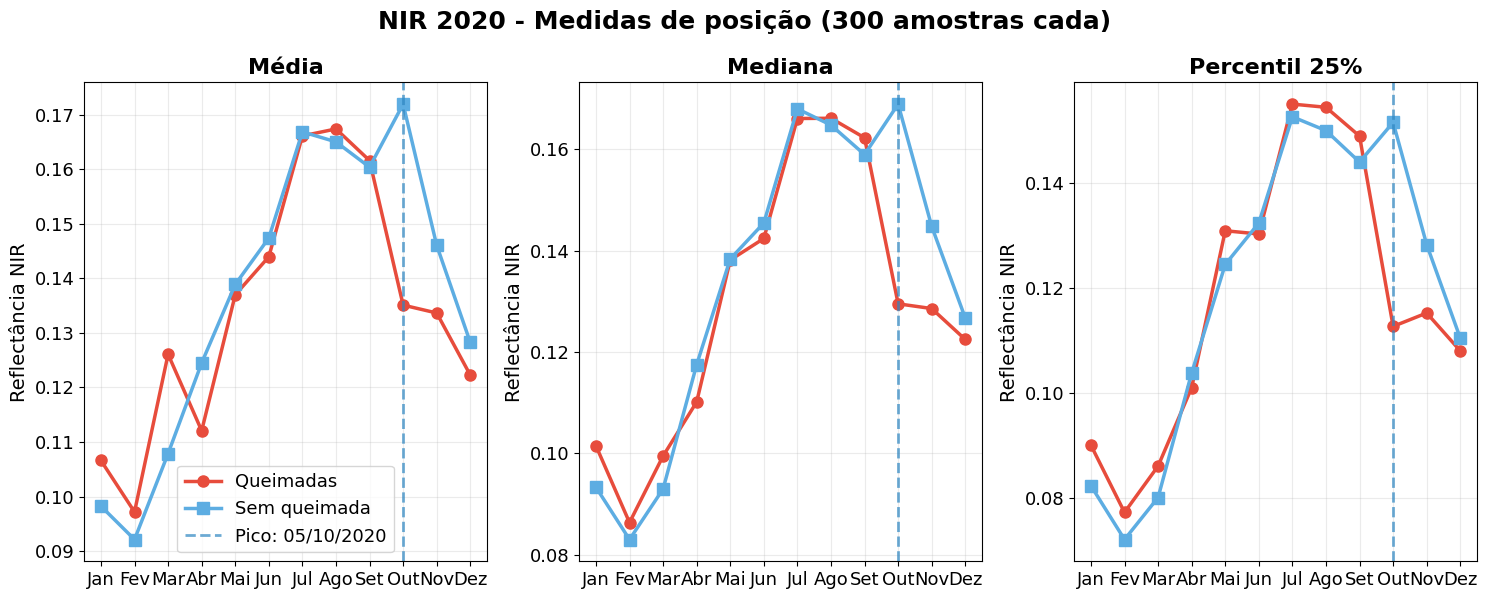

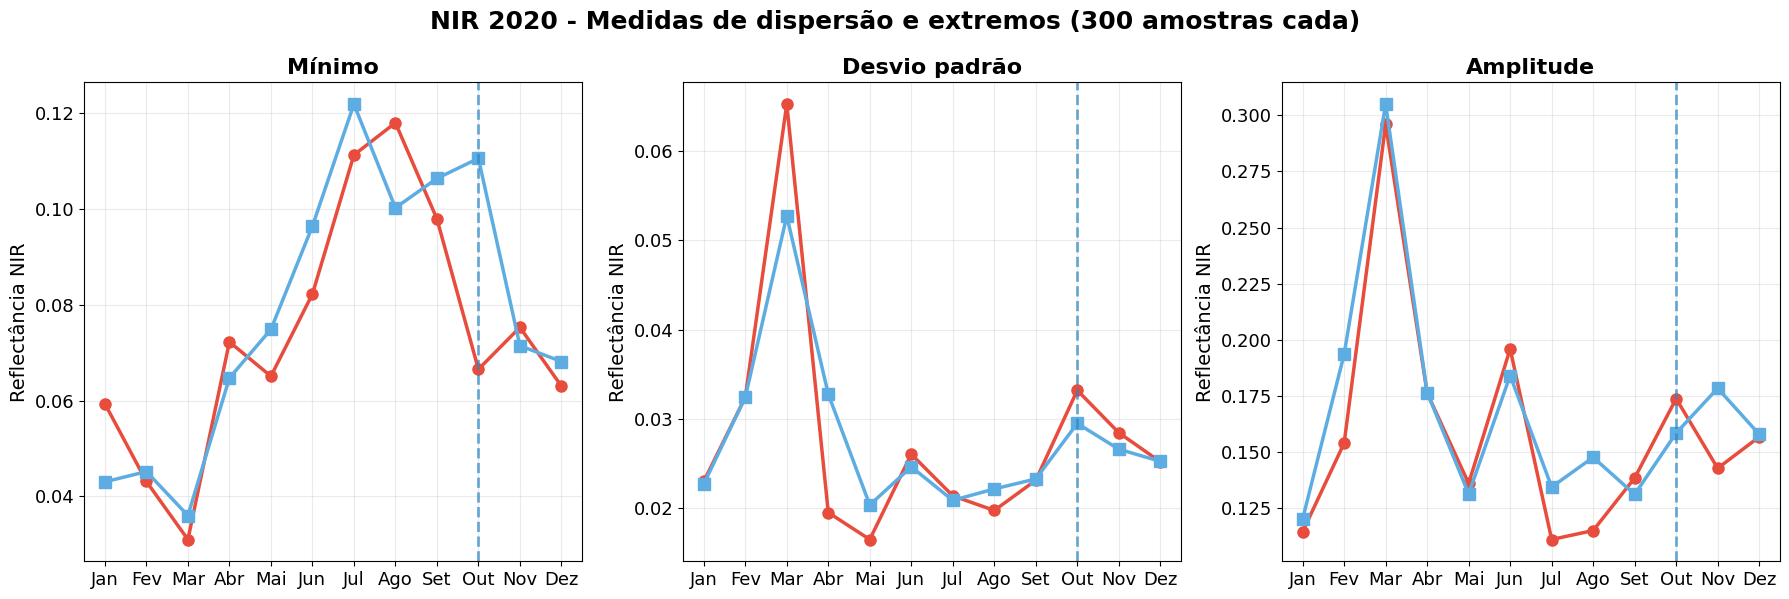

In [ ]:
# ============================================
# ANÁLISE ESPECTRAL NIR - NIR 2020 (MÉDIA, MEDIANA, P25, MIN, STD, AMPLITUDE)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

parquet_path = "/content/ScienceDB/Dataset/Dataset_WFI.parquet"

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# FUNÇÕES AUXILIARES
# ----------------------------------------------------------------------------

def get_nir_cols(ano):
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano):
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def agregar_por_mes(serie, nir_cols):
    dias_por_mes = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    medias = []
    idx = 0
    for dias_mes in dias_por_mes:
        grupo_cols = nir_cols[idx:idx + dias_mes]
        medias.append(serie[grupo_cols].mean())
        idx += dias_mes
    return np.array(medias)

def analisar_ano_mensal(ano, n_amostras=300):
    nir_cols = get_nir_cols(ano)
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None

    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False)
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    series_q = []
    series_sq = []

    for idx in amostras_q:
        series_q.append(agregar_por_mes(df.loc[idx, nir_cols], nir_cols))
    for idx in amostras_sq:
        series_sq.append(agregar_por_mes(df.loc[idx, nir_cols], nir_cols))

    series_q = np.array(series_q)
    series_sq = np.array(series_sq)

    data_obj = datetime.strptime(pico_data, "%d-%m-%y")

    return {
        "ano": ano,
        "media_q": series_q.mean(axis=0),
        "media_sq": series_sq.mean(axis=0),
        "mediana_q": np.median(series_q, axis=0),
        "mediana_sq": np.median(series_sq, axis=0),
        "p25_q": np.percentile(series_q, 25, axis=0),
        "p25_sq": np.percentile(series_sq, 25, axis=0),
        "min_q": series_q.min(axis=0),
        "min_sq": series_sq.min(axis=0),
        "std_q": series_q.std(axis=0),
        "std_sq": series_sq.std(axis=0),
        "amp_q": series_q.max(axis=0) - series_q.min(axis=0),
        "amp_sq": series_sq.max(axis=0) - series_sq.min(axis=0),
        "mes_pico": data_obj.month - 1,
        "data_pico": data_obj.strftime("%d/%m/%Y")
    }

# ----------------------------------------------------------------------------
# EXECUTAR
# ----------------------------------------------------------------------------

ano = 2020
print(f"\nAnalisando {ano}...")
r = analisar_ano_mensal(ano)

if r is None:
    print("Erro na análise")
    exit()

# ----------------------------------------------------------------------------
# GRÁFICOS
# ----------------------------------------------------------------------------

meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

cores = {"queimada": "#E74C3C", "sem_queimada": "#5DADE2", "pico": "#2E86C1"}
x = np.arange(12)

# Figura 1: Média, Mediana, Percentil 25%
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

metricas = [
    ("Média", "media_q", "media_sq"),
    ("Mediana", "mediana_q", "mediana_sq"),
    ("Percentil 25%", "p25_q", "p25_sq")
]

for i, (ax, (titulo, key_q, key_sq)) in enumerate(zip(axes, metricas)):
    ax.plot(x, r[key_q], color=cores["queimada"], linewidth=2.5, marker='o', markersize=8, label="Queimadas")
    ax.plot(x, r[key_sq], color=cores["sem_queimada"], linewidth=2.5, marker='s', markersize=8, label="Sem queimada")
    ax.axvline(r["mes_pico"], color=cores["pico"], linestyle="--", alpha=0.7, linewidth=2, label=f"Pico: {r['data_pico']}")
    ax.set_title(titulo, fontsize=16, fontweight="bold")
    ax.set_ylabel("Reflectância NIR", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(meses, fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(alpha=0.25)
    # Legenda apenas no primeiro frame (Média)
    if i == 0:
        ax.legend(fontsize=13, loc='best')
    ax.set_xlim(-0.5, 11.5)

fig.suptitle(f"NIR 2020 - Medidas de posição (300 amostras cada)", fontsize=18, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

# Figura 2: Mínimo, Desvio Padrão, Amplitude
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metricas = [
    ("Mínimo", "min_q", "min_sq"),
    ("Desvio padrão", "std_q", "std_sq"),
    ("Amplitude", "amp_q", "amp_sq")
]

for i, (ax, (titulo, key_q, key_sq)) in enumerate(zip(axes, metricas)):
    ax.plot(x, r[key_q], color=cores["queimada"], linewidth=2.5, marker='o', markersize=8, label="Queimadas")
    ax.plot(x, r[key_sq], color=cores["sem_queimada"], linewidth=2.5, marker='s', markersize=8, label="Sem queimada")
    ax.axvline(r["mes_pico"], color=cores["pico"], linestyle="--", alpha=0.7, linewidth=2)
    ax.set_title(titulo, fontsize=16, fontweight="bold")
    ax.set_ylabel("Reflectância NIR", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(meses, fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(alpha=0.25)
    # Sem legenda (já aparece no primeiro gráfico)
    ax.set_xlim(-0.5, 11.5)

fig.suptitle(f"NIR 2020 - Medidas de dispersão e extremos (300 amostras cada)", fontsize=18, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

Ao analisar individualmente os gráficos, observamos que o desvio-padrão e a amplitude são as métricas que menos distinguem as células com queimadas das células sem queimadas.

a) Desvio-padrão: mede o quanto os valores de reflectância dos pixels variam dentro de cada célula... assim, essa métrica descreve principalmente a variação entre os pixels da célula, e não a presença da queimada, o que reduz sua capacidade de diferenciar as duas classes.

b) Amplitude: representa a diferença entre o maior e o menor valor de reflectância dos pixels da célula e, assim como o desvio-padrão, é influenciada pela heterogeneidade espacial da cobertura presente... dado que  células queimadas e não queimadas podem apresentar diferentes níveis de heterogeneidade interna, essa métrica tende a refletir mais a variabilidade dos pixels do que a ocorrência de queimadas propriamente dita.

Contudo, essas são as únicas métricas em que as células com queimadas apresentam valores médios superiores aos das células sem queimadas no pico de detecções. Embora elas indiquem um menor poder discriminativo, devemos mantê-las no conjunto de atributos para que o algoritmo de *machine learning* (o que veremos no próximo Jupyter Notebook) determine sua contribuição para o mapeamento das áreas queimadas.

**Preparação dos dados para classificação**

Para finalizar este *notebook*, serão preparados os conjuntos de dados que servirão de entrada para a classificação com o algoritmo *Random Forest*, apresentada no *notebook* seguinte.

Vamos gerar três conjuntos de dados a partir do NIR:

a) daily_nir.parquet: contém as séries temporais diárias do NIR para os três anos analisados, preservando os nomes originais das colunas.

b) sixteen_nir.parquet: contém as séries do NIR agregadas em intervalos de 16 dias, com as métricas média, mediana, desvio-padrão, mínimo, percentil de 25% e amplitude.

c) thirty_nir.parquet: contém as séries do NIR agregadas em intervalos de 30 dias, utilizando as mesmas métricas da abordagem com 16 dias.

In [ ]:
# ============================================
# PREPARACAO DOS DADOS PARA CLASSIFICACAO
# ============================================

import pandas as pd
import numpy as np
import os

parquet_path = "/content/ScienceDB/Dataset/Dataset_WFI.parquet"

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

label_cols = ["date_20", "date_21", "date_22", "20_labels", "21_labels", "22_labels"]
df_labels = df[label_cols].copy()

BASE_DIR = "/content/ScienceDB/Dataset"
os.makedirs(BASE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# FUNÇÕES
# ----------------------------------------------------------------------------

def get_nir_cols(ano):
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def agregar_serie(serie, nir_cols, periodo):
    n = len(nir_cols)
    n_grupos = (n + periodo - 1) // periodo

    medias, medianas, stds, mins, p25s, amps = [], [], [], [], [], []

    for i in range(n_grupos):
        inicio = i * periodo
        fim = min((i + 1) * periodo, n)
        grupo = serie[nir_cols[inicio:fim]]

        medias.append(grupo.mean())
        medianas.append(grupo.median())
        stds.append(grupo.std())
        mins.append(grupo.min())
        p25s.append(grupo.quantile(0.25))
        amps.append(grupo.max() - grupo.min())

    return {'mean': np.array(medias), 'median': np.array(medianas),
            'std': np.array(stds), 'min': np.array(mins),
            'p25': np.array(p25s), 'amp': np.array(amps)}

def criar_dataset_agregado(ano, periodo):
    nir_cols = get_nir_cols(ano)
    if not nir_cols:
        return None

    nir_data = df[nir_cols].values
    results = []

    for i in range(len(nir_data)):
        serie = pd.Series(nir_data[i], index=nir_cols)
        metrics = agregar_serie(serie, nir_cols, periodo)

        row = {}
        for key, values in metrics.items():
            for k, val in enumerate(values):
                row[f"{key}_{k+1:03d}"] = val
        results.append(row)

    df_agg = pd.DataFrame(results)
    ano_str = str(ano)[-2:]
    df_agg['date'] = df_labels[f'date_{ano_str}']
    df_agg['label'] = df_labels[f'{ano_str}_labels']
    df_agg['year'] = ano

    return df_agg

# ----------------------------------------------------------------------------
# DATASET DIÁRIO
# ----------------------------------------------------------------------------

print("\nCriando daily_nir.parquet...")
nir_cols_all = sorted([col for col in df.columns if col.startswith('d_')])
df_daily_list = []

for ano in [2020, 2021, 2022]:
    ano_str = str(ano)[-2:]
    nir_cols_ano = [col for col in nir_cols_all if col.startswith(f'd_{ano_str}')]
    df_ano = df[nir_cols_ano + [f'date_{ano_str}', f'{ano_str}_labels']].copy()
    df_ano['year'] = ano
    df_daily_list.append(df_ano)

df_daily = pd.concat(df_daily_list, ignore_index=True)
df_daily.to_parquet(os.path.join(BASE_DIR, "daily_nir.parquet"))
print(f"daily_nir.parquet: {df_daily.shape[0]:,} linhas, {df_daily.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# DATASET DE 16 DIAS
# ----------------------------------------------------------------------------

print("\nCriando sixteen_nir.parquet...")
df_sixteen = None
for ano in [2020, 2021, 2022]:
    df_ano = criar_dataset_agregado(ano, 16)
    if df_ano is not None:
        df_sixteen = df_ano if df_sixteen is None else pd.concat([df_sixteen, df_ano], ignore_index=True)

if df_sixteen is not None:
    df_sixteen.to_parquet(os.path.join(BASE_DIR, "sixteen_nir.parquet"))
    print(f"sixteen_nir.parquet: {df_sixteen.shape[0]:,} linhas, {df_sixteen.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# DATASET DE 30 DIAS
# ----------------------------------------------------------------------------

print("\nCriando thirty_nir.parquet...")
df_thirty = None
for ano in [2020, 2021, 2022]:
    df_ano = criar_dataset_agregado(ano, 30)
    if df_ano is not None:
        df_thirty = df_ano if df_thirty is None else pd.concat([df_thirty, df_ano], ignore_index=True)

if df_thirty is not None:
    df_thirty.to_parquet(os.path.join(BASE_DIR, "thirty_nir.parquet"))
    print(f"thirty_nir.parquet: {df_thirty.shape[0]:,} linhas, {df_thirty.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# RESUMO
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("RESUMO DOS DATASETS GERADOS")
print("=" * 60)
print(f"\ndaily_nir.parquet: {df_daily.shape[0]:,} x {df_daily.shape[1]:,}")

if df_sixteen is not None:
    print(f"sixteen_nir.parquet: {df_sixteen.shape[0]:,} x {df_sixteen.shape[1]:,}")

if df_thirty is not None:
    print(f"thirty_nir.parquet: {df_thirty.shape[0]:,} x {df_thirty.shape[1]:,}")

print(f"\nDiretorio: {BASE_DIR}")

Carregando dados...
Dataset carregado: 38,957 linhas, 9,862 colunas

Criando daily_nir.parquet...
daily_nir.parquet: 116,871 linhas, 1,102 colunas

Criando sixteen_nir.parquet...
sixteen_nir.parquet: 116,871 linhas, 141 colunas

Criando thirty_nir.parquet...
thirty_nir.parquet: 116,871 linhas, 81 colunas

RESUMO DOS DATASETS GERADOS

daily_nir.parquet: 116,871 x 1,102
sixteen_nir.parquet: 116,871 x 141
thirty_nir.parquet: 116,871 x 81

Diretorio: /content/ScienceDB/Dataset


<small>O DeepSeek foi utilizado na padronização dos códigos.</small>

### **Então, qual é a melhor abordagem?**

Ao longo deste *notebook*, vimos que os dados diários podem ser transformados em dados agregados (por exemplo, em janelas de 16 ou 30 dias). Essa agregação pode facilitar a identificação de padrões temporais em algumas classes de uso e cobertura da terra, mas também pode reduzir informações importantes em outros casos.

**Principais benefícios da agregação**:

1) Redução da dimensionalidade, pois torna os dados mais simples de analisar.

2) Suavização da série temporal, pois reduz variações pontuais preservando tendências gerais.

3) Extração de métricas temporais, pois com a agregação várias estatísticas podem ser obtidas, como média, mediana, desvio padrão, etc.

**Principais limitações**:

1) Ruídos e/ou artefatos podem surgir pela presença de nuvens e/ou sombras.

2) Perda de detalhes temporais, especialmente quando o alvo possui mudanças rápidas ou padrões sutis.

A melhor estratégia depende do objetivo da análise e da dinâmica temporal de cada classe. A agregação pode destacar padrões gerais, mas deve ser aplicada com cuidado para não perder informações relevantes.

Link para o dataset: https://doi.org/10.57760/sciencedb.14040

**Bio**

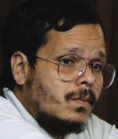

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1